In [41]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set_context('notebook')
from my_fun.my_fun import fig_size, save_notebook_files

In [42]:
# Magics
%load_ext autoreload
%autoreload 2

In [43]:
# Plotting style
sns.set_theme(style='ticks', context='notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

In [123]:
def plot_task_events(events):
    """
    Plot task events as a schematic timeline.
    :param events: List of tuples (name, start, duration)
                   start and duration can be either a float or a list of floats
    """

    # Flatten all start+duration to compute t_max
    all_times = []
    for _, start, duration, _ in events:
        if isinstance(start, (list, tuple)):
            all_times.extend([s + d for s, d in zip(start, duration)])
        else:
            all_times.append(start + duration)

    t_min = -2.5  # Stimulus load time
    t_max = max(all_times) + 0.5

    figsize = fig_size(n_cols=2)
    plt.figure(figsize=figsize, constrained_layout=True)

    for i, (name, start, duration, color) in enumerate(events):
        # Make lists if single values
        if not isinstance(start, (list, tuple)):
            start = [start]
            duration = [duration]

        # Determine indentation for the row (does not change actual start times)
        x_indent = 0.5 if name in ['Correct', 'Error'] else 0

        # Build x and y for all pulses in this row
        x = [t_min + x_indent]
        y = [0]

        for s, d in zip(start, duration):
            x.extend([s, s, s + d, s + d])
            y.extend([0, 1, 1, 0])
        x.append(t_max)
        y.append(0)

        y_offset = (len(events) - 1 - i) * 1.5
        y = [v + y_offset for v in y]

        plt.plot(x, y, color=color)
        plt.text(t_min + 0.05 + x_indent, y_offset + 0.5, name, va='center', color=color)

    plt.xlabel('Time (s)')
    plt.yticks([])
    plt.ylim(-0.5, len(events)*1.5)
    sns.despine(left=True)

# Plot task schematics

## Regular task

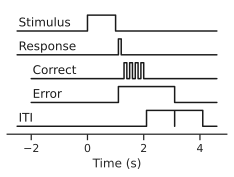

In [141]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 1, 'k'),
    ('Response', 1.1, 0.1, 'k'),  # Lick (spike like, 0 )
    ('Correct', [1.3, 1.5, 1.7, 1.9], [0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('Error', 1.1, 2, 'k'),  # Timeout
    ('ITI', [2.1, 3.1], [1, 1], 'k')  # Variable ITI
]

plot_task_events(events)

## Drug task schematic

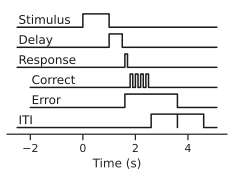

In [140]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 1, 'k'),
    ('Delay', 1, 0.5, 'k'),
    ('Response', 1.6, 0.1, 'k'),  # Lick (spike like, 0 )
    ('Correct', [1.8, 2, 2.2, 2.4], [0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('Error', 1.6, 2, 'k'),  # Timeout
    ('ITI', [2.6, 3.6], [1, 1], 'k')  # Variable ITI
]

plot_task_events(events)

## Ephys task schematic

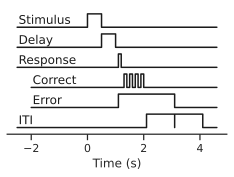

In [134]:
# Define events: (name, start, duration)
events = [
    ('Stimulus', 0, 0.5, 'k'),
    ('Delay', 0.5, 0.5, 'k'),
    ('Response', 1.1, 0.1, 'k'),
    # ('Feedback', 1.1, 1),
    ('Correct', [1.3, 1.5, 1.7, 1.9], [0.1, 0.1, 0.1, 0.1], 'k'),  # 5 licks
    ('Error', 1.1, 2, 'k'),  # Timeout
    ('ITI', [2.1, 3.1], [1, 1], 'k')  # Variable ITI
]

plot_task_events(events)

# Save all notebook's figures

In [143]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 3 images to notebook_files/
